# Homework 2

In [386]:
import numpy as np
import math
import matplotlib.pyplot as plt
import scipy as sp
from scipy.sparse import spdiags
import matplotlib.animation as animation

## Problem 1

In [387]:
pi = math.pi
n = 10
x = np.linspace(0, (2 * pi), n)
h = x[1] - x[0]

f = np.sin(x)
f1 = np.cos(x)
f2 = -np.sin(x)

### First Derivative Approximations

In [388]:
# first derivative second order accurate matrix multiplication
e = np.ones(n)
D2 = sp.sparse.diags([-e, e], [-1, 1], shape=(n, n)) / (2 * h)
D2 = D2.tolil()
D2[0, 0:3] = np.array([-3, 4, -1]) / (2 * h)
D2[n - 1, n - 3:n] = np.array([1, -4, 3]) / (2 * h)

In [389]:
f1_second_order = D2 @ f

In [390]:
# first derivative fourth order accurate matrix multiplication
e = np.ones(n)
D4 = sp.sparse.diags([e, -8 * e, 8 * e, -e], [-2, -1, 1, 2], shape=(n, n)) / (12 * h)
D4 = D4.tolil()
D4[0, 0:3] = np.array([-3, 4, -1]) / (2 * h)
D4[1, 1:4] = np.array([-3, 4, -1]) / (2 * h)
D4[n - 1, n - 3:n] = np.array([1, -4, 3]) / (2 * h)
D4[n - 2, n - 4:n-1] = np.array([1, -4, 3]) / (2 * h)

In [391]:
f1_fourth_order = D4 @ f

Text(0.5, 1.0, 'second vs. fourth order accurate finite difference approx. of $f^{(1)}(x)$')

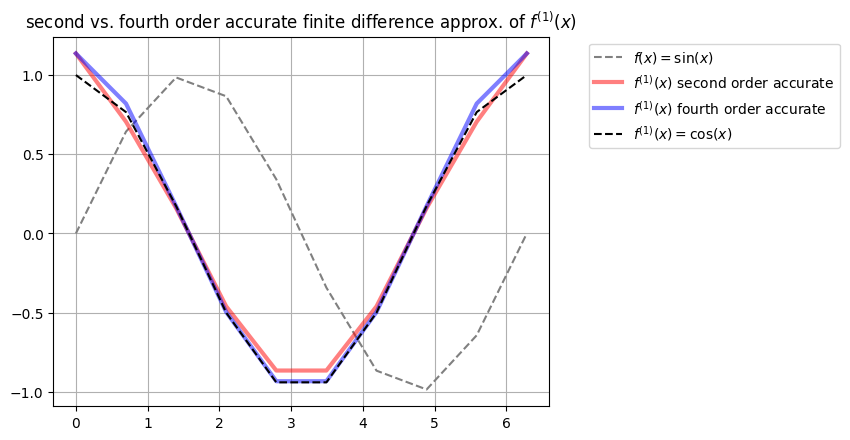

In [392]:
plt.plot(x, f, label=r'$f(x)=\sin(x)$', 
         color='gray', linestyle='dashed')
plt.plot(x, f1_second_order, label=r'$f^{(1)}(x)$ second order accurate', 
         color='red', lw=3, alpha=0.5)
plt.plot(x, f1_fourth_order, label=r'$f^{(1)}(x)$ fourth order accurate', 
         color='blue', lw=3, alpha=0.5)
plt.plot(x, f1, label=r'$f^{(1)}(x)=\cos(x)$', 
         color='black', linestyle='dashed')
plt.grid()
plt.legend(loc='upper right', bbox_to_anchor=(1.6, 1))
plt.title(r'second vs. fourth order accurate finite difference approx. of $f^{(1)}(x)$')

### Second Derivative Approximations

In [393]:
# second derivative second order accurate matrix multiplication
e = np.ones(n)
D2 = sp.sparse.diags([e, -2 * e, e], [-1, 0, 1], shape=(n, n)) / (h ** 2)
D2 = D2.tolil()
D2[0, 0:3] = np.array([1, -2, 1]) / (h**2)
D2[1, 1:4] = np.array([1, -2, 1]) / (h**2)
D2[n - 1, n - 3:n] = np.array([1, -2, 1]) / (h**2)
D2[n - 2, n - 4:n-1] = np.array([1, -2, 1]) / (h**2)
f2_second_order = D2 @ f

In [394]:
# fourth order accurate second derivative matrix multiplication
e = np.ones(n)
D4 = sp.sparse.diags([-e, 16 * e, -30 * e, 16 * e, -e], [-2, -1, 0, 1, 2], shape=(n, n)) / (12 * h ** 2)
D4 = D4.tolil()
D4[0, 0:3] = np.array([1, -2, 1]) / (h**2)
D4[1, 1:4] = np.array([1, -2, 1]) / (h**2)
D4[n - 1, n - 3:n] = np.array([1, -2, 1]) / (h**2)
D4[n - 2, n - 4:n-1] = np.array([1, -2, 1]) / (h**2)
f2_fourth_order = D4 @ f

Text(0.5, 1.0, 'second vs. fourth order accurate finite difference approx. of $f^{(2)}(x)$')

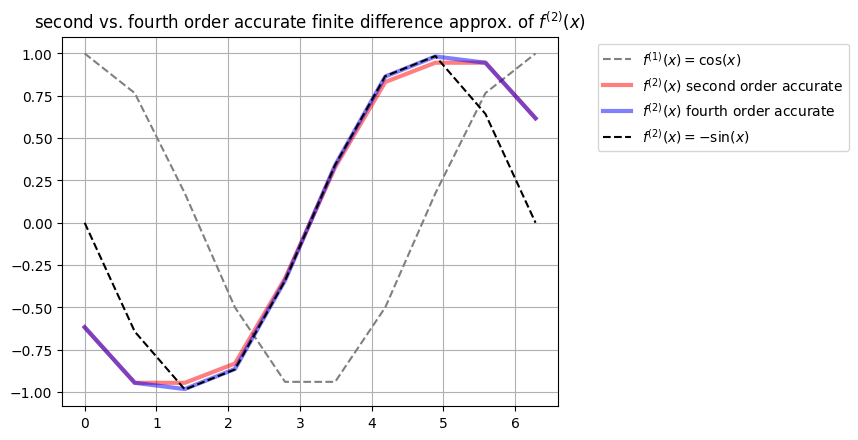

In [395]:
plt.plot(x, f1, label=r'$f^{(1)}(x)=\cos(x)$', 
         color='gray', linestyle='dashed')
plt.plot(x, f2_second_order, label=r'$f^{(2)}(x)$ second order accurate', 
         color='red', lw=3, alpha=0.5)
plt.plot(x, f2_fourth_order, label=r'$f^{(2)}(x)$ fourth order accurate',
            color='blue', lw=3, alpha=0.5)
plt.plot(x, f2, label=r'$f^{(2)}(x)=-\sin(x)$', 
         color='black', linestyle='dashed')
plt.grid()
plt.legend(loc='upper right', bbox_to_anchor=(1.6, 1))
plt.title(r'second vs. fourth order accurate finite difference approx. of $f^{(2)}(x)$')

## Problem 2

Note that the 1D advection equation is:

$$ \frac{\partial f}{\partial t} = D\frac{\partial^2 f}{\partial x^2}-c\frac{\partial f}{\partial x} $$

where $c$ is the advection speed and $D$ is the diffusion coefficient. The initial condition developed in class is a half period sine wave.

$$ f(x,0)=0.5\sin\left( \frac{\pi x}{L} \right) $$

For this initial condition the exact solution is:

$$ f(x,t)=0.5e^{-D\left(\frac{\pi}{L}\right)^2 t} \sin \left( \frac{\pi(x-ct)}{L} \right)$$

This can be used later to plot the final condition of the function. 

### Part A: Second-order discretization

Parameters:

In [624]:
n = [11, 21, 41, 81, 161]
L = 2 * np.pi
dt = 0.0005
T = 2
nstep = int(T / dt)
c = 1
D = 0.5

x = [np.linspace(0, L, n_i, endpoint=False) for n_i in n]
h = [L / n_i for n_i in n]  # spacing is now L/n, not L/(n-1)
f = [0.5 * np.sin(2*np.pi * x_i / L) for x_i in x]

First derivative matrix (advection term) — 2nd order centered differences.

In [625]:
def D2(h, f):
    n = len(f)
    e = np.ones(n)

    # Centered difference in the interior
    mat = spdiags([-e, 0*e, e], [-1, 0, 1], n, n) 
    mat = mat.toarray()

    # One-sided boundary stencils (2nd order)
    mat[0, n-1] = -1
    mat[n-1, 0] = 1

    mat = mat / (2 * h)
    return mat @ f

Second derivative matrix (diffusion term / Laplacian) — 2nd order centered differences.

In [626]:
def L2(h, f):
    n = len(f)
    e = np.ones(n)

    # Standard 3-point Laplacian stencil in the interior
    mat = spdiags([e, -2 * e, e], [-1, 0, 1], n, n)
    mat = mat.toarray()

    # One-sided boundary stencils (2nd order)
    mat[0, n-1] = 1
    mat[n-1, 0] = 1

    mat = mat / (h ** 2)
    return mat @ f

Time stepping:

In [627]:
f_all = []
for i in range(len(n)):
    f_i = f[i].copy()
    steps = []
    for step in range(nstep):
        dfdx  = c * D2(h[i], f_i)
        dfdx2 = D * L2(h[i], f_i)
        f_i = f_i + (dfdx2 - dfdx) * dt
    f_all.append(f_i)

Plot the function values for each grid size at the final time step. Also showing the initial condition for comparison. 

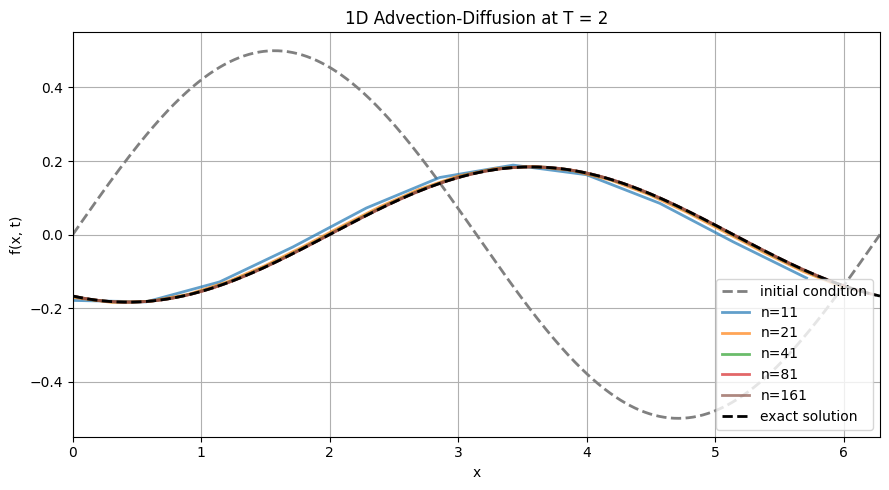

In [628]:
x_exact = np.linspace(0, L, 1000)
f_exact = 0.5 * np.exp(-D * (2*np.pi / L)**2 * T) * np.sin(2*np.pi * (x_exact - c * T) / L)
x_ic = np.linspace(0, L, 1000)
f_ic = 0.5 * np.sin(2*np.pi * x_ic / L)

fig, ax = plt.subplots(figsize=(9, 5))

ax.grid()
colors = plt.cm.tab10(np.linspace(0, 0.5, len(n)))
ax.plot(x_ic, f_ic, color='gray', linewidth=2, linestyle='--', label='initial condition')
for i in range(len(n)):
    ax.plot(x[i], f_all[i], color=colors[i], linewidth=2, label=f'n={n[i]}', alpha=0.7)
ax.plot(x_exact, f_exact, color='black', linewidth=2, linestyle='--', label='exact solution')

ax.set_xlim(0, L)
ax.set_xlabel('x')
ax.set_ylabel('f(x, t)')
ax.set_title(f'1D Advection-Diffusion at T = {T}')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

Error calculations:

In [629]:
errors = []
for i in range(len(n)):
    f_exact_i = 0.5 * np.exp(-D * (np.pi / L)**2 * T) * np.sin(np.pi * (x[i] - c * T) / L)
    E = np.sqrt(h[i] * np.sum((f_all[i] - f_exact_i)**2))
    errors.append(E)

In [630]:
inv_h = [1 / h_i for h_i in h]

coeffs = np.polyfit(np.log(inv_h), np.log(errors), 1)
slope = coeffs[0]
fit_line = np.exp(np.polyval(coeffs, np.log(inv_h)))

Plot the error for each grid size.

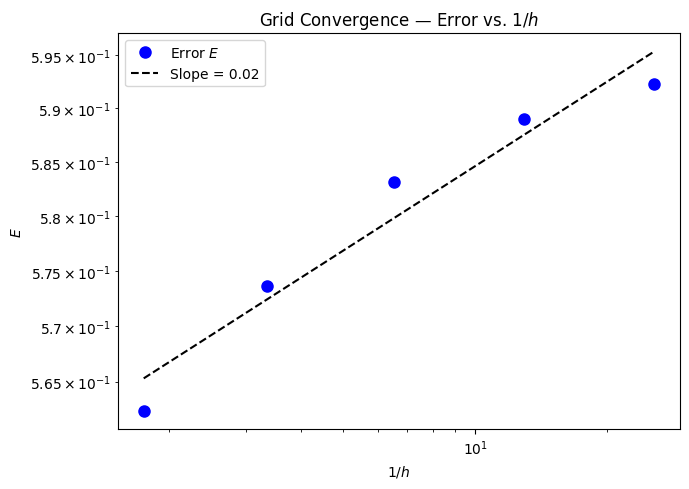

In [631]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(inv_h, errors, 'o', markersize=8, label='Error $E$', color='blue')
ax.loglog(inv_h, fit_line, '--', color='black', label=f'Slope = {slope:.2f}')
ax.set_xlabel('$1/h$')
ax.set_ylabel('$E$')
ax.set_title('Grid Convergence — Error vs. $1/h$')
ax.legend()
plt.tight_layout()
plt.show()

### Part B: Fourth-order discretization.

Edit the approximation functions so that they are now fourth order.

In [632]:
def D2_4th(h, f):
    """First derivative matrix (advection term) — 4th order centered differences."""
    n = len(f)
    e = np.ones(n)

    # 4th order centered difference interior stencil: [-1, 8, 0, -8, 1] / 12h
    mat = spdiags([e, -8*e, 8*e, -e], [-2, -1, 1, 2], n, n) / (12 * h)
    mat = mat.toarray()

    # 4th order one-sided boundary stencils
    # Left boundaries (rows 0 and 1)
    mat[0, 0:5] = np.array([-25, 48, -36, 16, -3]) / (12 * h)
    mat[1, 0:5] = np.array([-3, -10, 18, -6, 1])   / (12 * h)

    # Right boundaries (rows n-1 and n-2)
    mat[n-1, n-5:n] = np.array([3, -16, 36, -48, 25]) / (12 * h)
    mat[n-2, n-5:n] = np.array([-1, 6, -18, 10, 3])   / (12 * h)

    return mat @ f

def L2_4th(h, f):
    """Second derivative matrix (diffusion term) — 4th order centered differences."""
    n = len(f)
    e = np.ones(n)

    # 4th order centered difference interior stencil: [-1, 16, -30, 16, -1] / 12h^2
    mat = spdiags([-e, 16*e, -30*e, 16*e, -e], [-2, -1, 0, 1, 2], n, n) / (12 * h**2)
    mat = mat.toarray()

    # 4th order one-sided boundary stencils
    # Left boundaries (rows 0 and 1)
    mat[0, 0:6] = np.array([45, -154, 214, -156, 61, -10]) / (12 * h**2)
    mat[1, 0:6] = np.array([10, -15, -4,  14,  -6,   1])   / (12 * h**2)

    # Right boundaries (rows n-1 and n-2)
    mat[n-1, n-6:n] = np.array([-10, 61, -156, 214, -154, 45]) / (12 * h**2)
    mat[n-2, n-6:n] = np.array([1,  -6,   14,  -4,  -15,  10]) / (12 * h**2)

    return mat @ f

Step the function forward in time. 

In [633]:
f_all_4th = []
for i in range(len(n)):
    f_i = f[i].copy()
    for step in range(nstep):
        dfdx  = c * D2_4th(h[i], f_i)
        dfdx2 = D * L2_4th(h[i], f_i)
        f_i = f_i + (dfdx2 - dfdx) * dt
        f_i[0]  = f_i[-2]
        f_i[-1] = f_i[1]
    f_all_4th.append(f_i)

Plot the function values. 

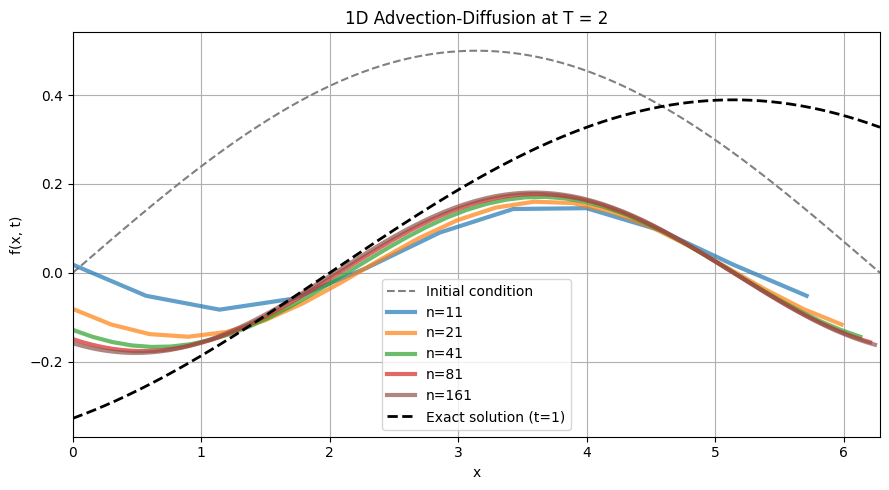

In [634]:
x_ref = np.linspace(0, L, 1000)
f_ic = 0.5 * np.sin(np.pi * x_ref / L)
f_exact = 0.5 * np.exp(-D * (np.pi / L)**2 * T) * np.sin(np.pi * (x_ref - c * T) / L)
fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.tab10(np.linspace(0, 0.5, len(n)))
ax.plot(x_ref, f_ic,    color='gray',  linewidth=1.5, linestyle='--', label='Initial condition')
for i in range(len(n)):
    ax.plot(x[i], f_all_4th[i], color=colors[i], linewidth=3, label=f'n={n[i]}', alpha=0.7)
ax.plot(x_ref, f_exact, color='black', linewidth=2,   linestyle='--', label='Exact solution (t=1)')
ax.set_xlim(0, L)
ax.set_xlabel('x')
ax.set_ylabel('f(x, t)')
ax.set_title(f'1D Advection-Diffusion at T = {T}')
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

Plot the error.

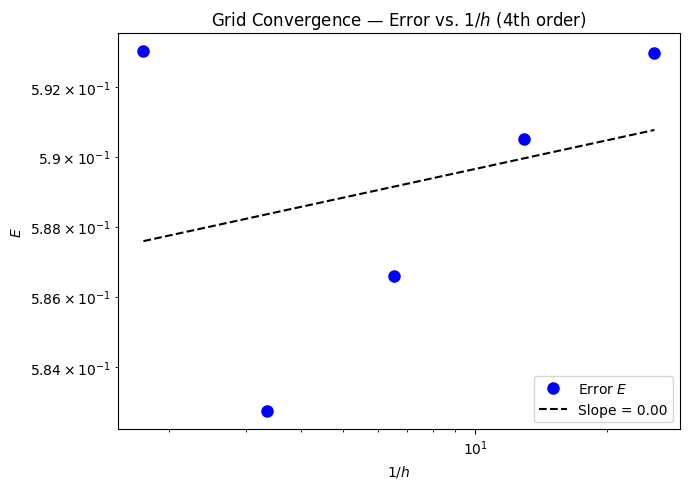

In [635]:
# --- Convergence plot ---
errors_4th = []
for i in range(len(n)):
    f_exact_i = 0.5 * np.exp(-D * (np.pi / L)**2 * T) * np.sin(np.pi * (x[i] - c * T) / L)
    E = np.sqrt(h[i] * np.sum((f_all_4th[i] - f_exact_i)**2))
    errors_4th.append(E)

coeffs_4th = np.polyfit(np.log(inv_h), np.log(errors_4th), 1)
slope_4th = coeffs_4th[0]
fit_line_4th = np.exp(np.polyval(coeffs_4th, np.log(inv_h)))

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(inv_h, errors_4th, 'o', markersize=8, label='Error $E$', color='blue')
ax.loglog(inv_h, fit_line_4th, '--', color='black', label=f'Slope = {slope_4th:.2f}')
ax.set_xlabel('$1/h$')
ax.set_ylabel('$E$')
ax.set_title('Grid Convergence — Error vs. $1/h$ (4th order)')
ax.legend()
plt.tight_layout()
plt.show()